In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel("/content/drive/MyDrive/Clean_Product_Sales.xlsx")

Step 1: Data Understanding

In [ ]:
data.shape

(1500, 19)

In [ ]:
data.columns

Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName',
       'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager'],
      dtype='object')

In [ ]:
data.dtypes

,0
Date,datetime64[ns]
Region,object
Product,object
Quantity,int64
UnitPrice,float64
StoreLocation,object
CustomerType,object
Discount,float64
Salesperson,object
TotalPrice,float64


In [ ]:
data.head(5)

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2333.740,Online,Freeship,0,Reg100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,549.310,Gift Card,Save10,0,Reg100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4382.328,Online,Winter15,0,Reg100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5915.696,Gift Card,Freeship,0,Reg100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4285.410,Online,Save10,0,Reg100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [ ]:
data.describe()

,Date,Quantity,UnitPrice,Discount,TotalPrice,Returned,ShippingCost,OrderDate,DeliveryDate
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500
mean,2024-04-07 21:35:02.400000256,10.410667,298.826947,0.073133,2947.502246,0.248000,27.507293,2024-04-07 21:35:02.400000256,2024-04-13 22:36:28.799999744
min,2023-01-01 00:00:00,1.000000,5.520000,0.000000,29.100000,0.000000,5.010000,2023-01-01 00:00:00,2023-01-08 00:00:00
25%,2023-08-20 00:00:00,5.000000,151.020000,0.000000,891.433625,0.000000,16.700000,2023-08-20 00:00:00,2023-08-25 12:00:00
50%,2024-04-08 12:00:00,11.000000,294.740000,0.050000,2200.965000,0.000000,27.100000,2024-04-08 12:00:00,2024-04-15 12:00:00
75%,2024-12-07 06:00:00,15.000000,446.702500,0.100000,4432.476000,0.000000,38.635000,2024-12-07 06:00:00,2024-12-13 06:00:00
max,2025-06-30 00:00:00,20.000000,599.720000,0.150000,11110.210000,1.000000,49.980000,2025-06-30 00:00:00,2025-07-10 00:00:00
std,NaN,5.735732,169.100075,0.055979,2522.697778,0.431996,13.093453,NaN,NaN


Step 2: Data Preperation


In [ ]:
data.isna().sum()

,0
Date,0
Region,0
Product,0
Quantity,0
UnitPrice,0
StoreLocation,0
CustomerType,0
Discount,0
Salesperson,0
TotalPrice,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data["OrderDate"] = pd.to_datetime(data["OrderDate"])
data["DeliveryDate"] = pd.to_datetime(data["DeliveryDate"])

data["DeliveryDays"] = (data["DeliveryDate"] - data["OrderDate"]).dt.days


In [ ]:
cost_ratios = {
    'Laptop': 0.80,
    'Tablet': 0.75,
    'Phone': 0.75,
    'Monitor': 0.70,
    'Printer': 0.65,
    'Desk': 0.55,
    'Chair': 0.55
}

# --------------------------------------------------
# 2) Estimate Unit Cost
# --------------------------------------------------
data['UnitCost'] = data['UnitPrice'] * data['Product'].map(cost_ratios)

# --------------------------------------------------
# 3) Revenue after discount
# --------------------------------------------------
data['Revenue'] = data['Quantity'] * data['UnitPrice'] * (1 - data['Discount'])

# --------------------------------------------------
# 4) Cost of Goods Sold (COGS)
# --------------------------------------------------
data['COGS'] = data['Quantity'] * data['UnitCost']

# --------------------------------------------------
# 5) Profit and Profit Margin
# --------------------------------------------------
data['Profit'] = data['Revenue'] - data['COGS']
data['ProfitMargin'] = (data['Profit'] / data['Revenue']) * 100

Step 3: Feature Understanding

In [ ]:
avg_delivery = data.groupby("Product")["DeliveryDays"].mean()
avg_delivery


,DeliveryDays
Product,
Chair,5.861244
Desk,6.111111
Laptop,6.030973
Monitor,6.320755
Phone,5.702564
Printer,6.099526
Tablet,6.133333


In [ ]:
data.groupby("PaymentMethod")["DeliveryDays"].mean()


,DeliveryDays
PaymentMethod,
Cash,5.926282
Credit Card,6.070234
Debit Card,6.082759
Gift Card,6.286232
Online,5.885449


In [ ]:
data["Late"] = data["DeliveryDays"] > 5

late_rate = data.groupby("Product")["Late"].mean() * 100
late_rate


,Late
Product,
Chair,52.153110
Desk,57.487923
Laptop,57.079646
Monitor,58.962264
Phone,51.282051
Printer,60.189573
Tablet,56.250000


In [ ]:
data.groupby(["Product", "Late"]).size()


Product  Late 
Chair    False    100
         True     109
Desk     False     88
         True     119
Laptop   False     97
         True     129
Monitor  False     87
         True     125
Phone    False     95
         True     100
Printer  False     84
         True     127
Tablet   False    105
         True     135
dtype: int64

In [ ]:
data.groupby("Late")["Discount"].mean()


,Discount
Late,
False,0.07378
True,0.07263


In [ ]:
data["OrderMonth"] = data["OrderDate"].dt.to_period("M")

data.groupby("OrderMonth")["DeliveryDays"].mean()


,DeliveryDays
OrderMonth,
2023-01,5.576923
2023-02,5.673469
2023-03,6.016949
2023-04,5.595238
2023-05,6.478261
2023-06,5.914894
2023-07,6.021739
2023-08,5.578947
2023-09,5.647059


In [ ]:
summary = data.groupby("Product").agg(
    avg_delivery_days=("DeliveryDays", "mean"),
    late_rate_percent=("Late", lambda x: x.mean() * 100),
    total_orders=("DeliveryDays", "count")
)

summary


,avg_delivery_days,late_rate_percent,total_orders
Product,,,
Chair,5.861244,52.153110,209
Desk,6.111111,57.487923,207
Laptop,6.030973,57.079646,226
Monitor,6.320755,58.962264,212
Phone,5.702564,51.282051,195
Printer,6.099526,60.189573,211
Tablet,6.133333,56.250000,240


In [ ]:
data["Promotion"].value_counts()

,count
Promotion,
Freeship,419
Winter15,373
No Promotion,370
Save10,338


In [ ]:
total_sales=data.groupby("Product")["Quantity"].sum()
total_sales

,Quantity
Product,
Chair,2122
Desk,2026
Laptop,2408
Monitor,2177
Phone,1970
Printer,2336
Tablet,2577


In [ ]:
total_discount=data.groupby("Product")["Discount"].mean()
total_discount

,Discount
Product,
Chair,0.071292
Desk,0.074879
Laptop,0.074558
Monitor,0.074528
Phone,0.070000
Printer,0.077014
Tablet,0.069792


In [ ]:
max_discount=data.groupby("Product")["Discount"].max()
max_discount

,Discount
Product,
Chair,0.15
Desk,0.15
Laptop,0.15
Monitor,0.15
Phone,0.15
Printer,0.15
Tablet,0.15


In [ ]:
sales_p=data.groupby("Salesperson")["TotalPrice"].sum()
sales_p


,TotalPrice
Salesperson,
Alice,793373.3400
Bob,803374.6515
Carlos,714574.9360
Diana,683634.8495
Eva,704894.3495
Frank,721401.2420


In [ ]:
bay_in_reg=data.groupby(["Region","Product"])["Quantity"].sum()
bay_in_reg

Region   Product
Central  Chair      381
         Desk       433
         Laptop     485
         Monitor    446
         Phone      290
         Printer    489
         Tablet     578
East     Chair      378
         Desk       398
         Laptop     528
         Monitor    364
         Phone      539
         Printer    456
         Tablet     415
North    Chair      489
         Desk       581
         Laptop     418
         Monitor    523
         Phone      353
         Printer    515
         Tablet     563
South    Chair      482
         Desk       256
         Laptop     544
         Monitor    345
         Phone      495
         Printer    446
         Tablet     385
West     Chair      392
         Desk       358
         Laptop     433
         Monitor    499
         Phone      293
         Printer    430
         Tablet     636
Name: Quantity, dtype: int64

In [ ]:
the_most_exp=data.groupby("Product")[["TotalPrice","UnitPrice"]].sum()
the_most_exp


,TotalPrice,UnitPrice
Product,,
Chair,627923.3380,66818.04
Desk,560918.5345,61102.39
Laptop,690854.6815,68643.72
Monitor,657451.6425,67266.89
Phone,502453.7210,52882.49
Printer,690254.0955,63707.93
Tablet,691397.3555,67818.96


In [ ]:
the_most_store_sales=data.groupby(["StoreLocation","Product"])["Quantity"].sum()
the_most_store_sales

StoreLocation  Product
Store A        Chair      652
               Desk       419
               Laptop     591
               Monitor    540
               Phone      522
               Printer    699
               Tablet     522
Store B        Chair      486
               Desk       593
               Laptop     535
               Monitor    303
               Phone      537
               Printer    565
               Tablet     662
Store C        Chair      501
               Desk       456
               Laptop     606
               Monitor    609
               Phone      378
               Printer    646
               Tablet     655
Store D        Chair      483
               Desk       558
               Laptop     676
               Monitor    725
               Phone      533
               Printer    426
               Tablet     738
Name: Quantity, dtype: int64

In [ ]:
my_sales_type=data.groupby(["Product","CustomerType"])["TotalPrice"].sum()
my_sales_type

Product  CustomerType
Chair    Retail          328847.6140
         Wholesale       299075.7240
Desk     Retail          258573.1755
         Wholesale       302345.3590
Laptop   Retail          310644.2820
         Wholesale       380210.3995
Monitor  Retail          334218.8740
         Wholesale       323232.7685
Phone    Retail          284050.4890
         Wholesale       218403.2320
Printer  Retail          339586.6695
         Wholesale       350667.4260
Tablet   Retail          359938.8190
         Wholesale       331458.5365
Name: TotalPrice, dtype: float64

In [ ]:
the_most_sales=data.groupby(["Region","StoreLocation"])["TotalPrice"].sum()
the_most_sales

Region   StoreLocation
Central  Store A          215204.4320
         Store B          191649.6385
         Store C          200299.3715
         Store D          248394.8025
East     Store A          238846.7385
         Store B          222102.3125
         Store C          204862.6990
         Store D          226617.2780
North    Store A          198046.9775
         Store B          220536.2750
         Store C          288866.3735
         Store D          268511.3540
South    Store A          225608.7695
         Store B          218221.9755
         Store C          188142.2185
         Store D          204186.7535
West     Store A          221091.0565
         Store B          187132.8110
         Store C          184044.1100
         Store D          268887.4215
Name: TotalPrice, dtype: float64

In [ ]:
the_most_pru=data.groupby(["PaymentMethod","Product"])["Quantity"].sum()
the_most_pru

PaymentMethod  Product
Cash           Chair      413
               Desk       458
               Laptop     559
               Monitor    476
               Phone      365
               Printer    551
               Tablet     492
Credit Card    Chair      469
               Desk       489
               Laptop     475
               Monitor    436
               Phone      375
               Printer    317
               Tablet     519
Debit Card     Chair      402
               Desk       382
               Laptop     415
               Monitor    384
               Phone      436
               Printer    433
               Tablet     527
Gift Card      Chair      380
               Desk       340
               Laptop     336
               Monitor    406
               Phone      340
               Printer    477
               Tablet     541
Online         Chair      458
               Desk       357
               Laptop     623
               Monitor    475
               Phone      454
               Printer    558
               Tablet     498
Name: Quantity, dtype: int64

In [ ]:
total_pruch_per_type=data.groupby("PaymentMethod")["TotalPrice"].sum()
total_pruch_per_type

,TotalPrice
PaymentMethod,
Cash,958980.4590
Credit Card,874760.4845
Debit Card,778395.7540
Gift Card,829014.2410
Online,980102.4300


In [ ]:
total_shiping_cost_per_product=data.groupby("Product")["ShippingCost"].sum()
total_shiping_cost_per_product

,ShippingCost
Product,
Chair,5333.86
Desk,5651.87
Laptop,6437.44
Monitor,5822.25
Phone,5290.87
Printer,5866.68
Tablet,6857.97


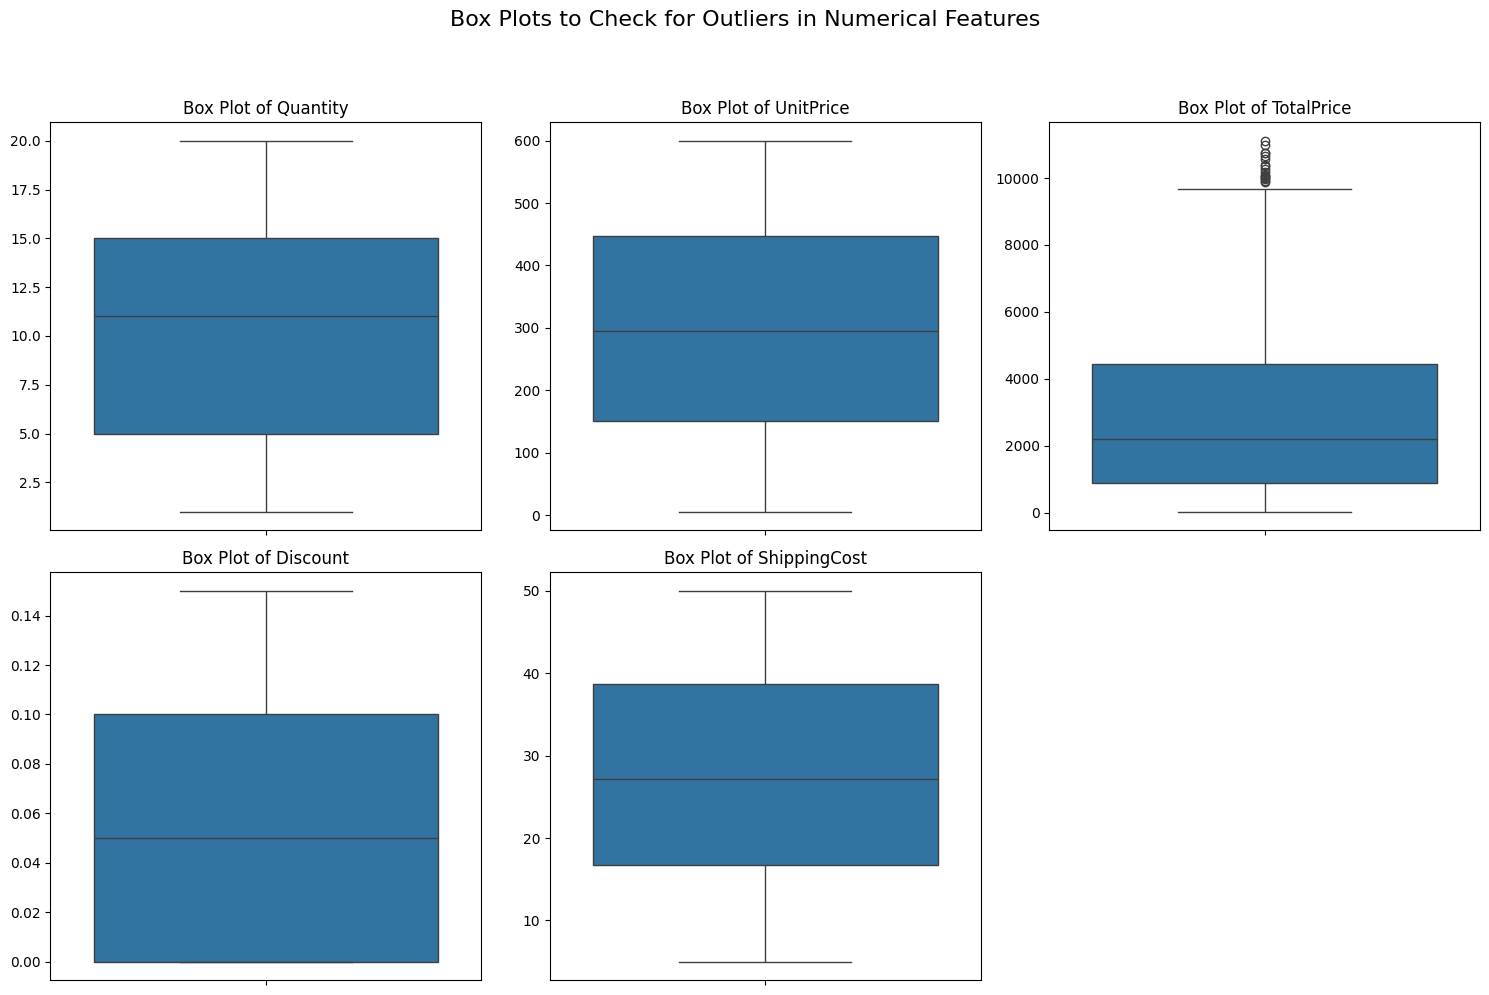

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'Discount', 'ShippingCost']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')

plt.suptitle('Box Plots to Check for Outliers in Numerical Features', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Sales and Delivery Insights Report

## Delivery Insights
- The average delivery time for all products is around **5–6 days**.  
- Payment method has little effect on delivery time, slightly longer for **Gift Card** orders.  
- The late delivery rate is high (**50–60%**) based on a 5-day threshold. The product with the most late deliveries is **Printer** at **60%** on average.  
- Late deliveries have minimal impact on discounts (**0.115%** of late orders received a discount).  
- Delivery timing is not significantly affected by holidays or seasonal delays.  

**Summary by Product:**

| Product | Avg Delivery Days | Late Rate (%) | Total Orders |
|---------|-----------------|---------------|-------------|
| Chair   | 5.86            | 52.15         | 209         |
| Desk    | 6.11            | 57.49         | 207         |
| Laptop  | 6.03            | 57.08         | 226         |
| Monitor | 6.32            | 58.96         | 212         |
| Phone   | 5.70            | 51.28         | 195         |
| Printer | 6.10            | 60.19         | 211         |
| Tablet  | 6.13            | 56.25         | 240         |

---

## Product Quantity and Discounts
- **Tablet** has the highest total quantity (**2,577 units**).  
- Average discount is lowest for **Tablet** (**0.069**) and highest for **Printer** (**0.077**).  
- Maximum discount is the same across all products (**15%**).  

---

## Salesperson Performance
- **Highest sales:** Bob (**803,374**)  
- **Lowest sales:** Diana (**683,634**)  

---

## Regional Product Sales

| Region  | Highest Product | Sales | Lowest Product | Sales |
|---------|----------------|-------|----------------|-------|
| Central | Tablet          | 578   | Phone           | 290   |
| East    | Phone           | 539   | Monitor         | 364   |
| North   | Desk            | 581   | Phone           | 353   |
| South   | Laptop          | 544   | Desk            | 256   |
| West    | Tablet          | 636   | Phone           | 293   |

- **Tablets and Laptops dominate** in several regions.  
- **Phones are the lowest-selling** product in most regions.  
- **Highest-selling product overall:** Tablet (**691,397.36**)  
- **Lowest-selling product overall:** Phone (**502,453.72**)  
- **Unit price:** Tablet (**67,818.96**), Phone (**52,882.49**)  

---

## Store Performance

| Store Location | Highest Product | Quantity | Lowest Product | Quantity |
|----------------|----------------|---------|----------------|---------|
| Store A        | Printer         | 699     | Desk           | 419     |
| Store B        | Tablet          | 662     | Monitor        | 303     |
| Store C        | Printer         | 646     | Phone          | 378     |
| Store D        | Tablet          | 738     | Printer        | 426     |

- **Tablets and Printers frequently appear as top-selling products**.  
- **Monitors and Phones** tend to have lower quantities.  
- **Store D** shows the highest single quantity (Tablet: 738), indicating strong demand or availability.  

---

## Customer Type Sales

| Product  | Higher Customer Type | Value       | Lower Customer Type | Value       |
|----------|-------------------|------------|-------------------|------------|
| Chair    | Retail            | 328,847.61 | Wholesale         | 299,075.72 |
| Desk     | Wholesale         | 302,345.36 | Retail            | 258,573.18 |
| Laptop   | Wholesale         | 380,210.40 | Retail            | 310,644.28 |
| Monitor  | Retail            | 334,218.87 | Wholesale         | 323,232.77 |
| Phone    | Retail            | 284,050.49 | Wholesale         | 218,403.23 |
| Printer  | Wholesale         | 350,667.43 | Retail            | 339,586.67 |
| Tablet   | Retail            | 359,938.82 | Wholesale         | 331,458.54 |

- **Wholesale customers** generate higher sales for Desk, Laptop, and Printer.  
- **Retail customers** generate higher sales for Chair, Monitor, Phone, and Tablet.  
- Laptop shows the largest gap in favor of Wholesale customers.  
- Phone relies heavily on Retail customers.  

---

## Store Revenue by Region

| Region  | Highest Store | Value       | Lowest Store | Value       |
|---------|---------------|------------|-------------|------------|
| Central | Store D       | 248,394.80 | Store B     | 191,649.64 |
| East    | Store A       | 238,846.74 | Store C     | 204,862.70 |
| North   | Store C       | 288,866.37 | Store A     | 198,046.98 |
| South   | Store A       | 225,608.77 | Store C     | 188,142.22 |
| West    | Store D       | 268,887.42 | Store C     | 184,044.11 |

- **Store D** performs best in Central and West.  
- **Store C** shows mixed results: strongest in North, weakest in South and West.  

---

## Payment Method Product Sales

| Payment Method | Highest Product | Quantity | Lowest Product | Quantity |
|----------------|----------------|---------|----------------|---------|
| Cash           | Laptop         | 559     | Phone          | 365     |
| Credit Card    | Tablet         | 519     | Printer        | 317     |
| Debit Card     | Tablet         | 527     | Desk           | 382     |
| Gift Card      | Tablet         | 541     | Laptop         | 336     |
| Online         | Laptop         | 623     | Desk           | 357     |

- Tablet is highest-selling for Credit Card, Debit Card, and Gift Card.  
- Laptop is highest for Cash and Online.  

---

## Payment Method Revenue

| Payment Method | TotalPrice   | Highest Product | Qty | Lowest Product | Qty |
|----------------|-------------|----------------|-----|----------------|-----|
| Cash           | 958,980.46  | Laptop         | 559 | Phone          | 365 |
| Credit Card    | 874,760.48  | Tablet         | 519 | Printer        | 317 |
| Debit Card     | 778,395.75  | Tablet         | 527 | Desk           | 382 |
| Gift Card      | 829,014.24  | Tablet         | 541 | Laptop         | 336 |
| Online         | 980,102.43  | Laptop         | 623 | Desk           | 357 |

**Key Points:**  
1. Online and Cash bring the most revenue.  
2. Laptop and Tablet are the most sold products.  
3. Low-selling products differ by payment method.  
4. High sales don’t always mean highest revenue.  

---

## Shipping Cost

| Type             | Product  | ShippingCost |
|-----------------|----------|--------------|
| Highest Shipping | Tablet   | 6,857.97     |
| Lowest Shipping  | Phone    | 5,290.87     |

- Tech products (Laptop, Tablet, Printer) cost more to ship than furniture (Chair, Desk, Monitor).  
- Shipping cost generally increases with product value or weight.  


In [ ]:
data.to_excel('data after EDA.xlsx', index=False)
print("Cleaned data saved as 'data after EDA.xlsx'")